In [ ]:
from google.colab import files
import pandas as pd

# Upload two CSV files
uploaded = files.upload()  # Prompts you to upload files

# Read them into DataFrames
import io




Saving train_data.csv to train_data.csv
Saving test_data.csv to test_data.csv


In [ ]:
import pandas as pd

# Read the CSV files with updated names
train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

# Preview first few rows
print("Train Data:")
print(train_df.head())

print("\nTest Data:")
print(test_df.head())


Train Data:
                                               Tweet   Sentiment  \
0  @roz_avanthay @pinemikey @PierrePoilievre As a...  Strong_Pos   
1  Go Canada Truckers, GOoooooo!\nTruckers Freedo...  Strong_Pos   
2  The #FreedomConvoy knew Chris Barber was refer...  Strong_Pos   
3  LIVE CONVOY IN OTTAWA -  SATURDAY CANADA EXPOS...    Mild_Neg   
4  @PeterDooleyDUB Trudeau said avoid anti-vaxx t...  Strong_Pos   

                                         Clean_Tweet Sentiment_3class  \
0  as a 2nd yr student in 1999 he wrote an essay ...         Positive   
1  go canada truckers gooooooo truckers freedom c...         Positive   
2  the knew chris barber was referring to tamara ...         Positive   
3  live convoy in ottawa saturday canada exposing...         Negative   
4  trudeau said avoid antivaxx truckers no one to...         Positive   

   Sentiment_Label  tweet_length  
0                2           147  
1                2           103  
2                2           251  


In [ ]:
# Clean the 'Clean_Tweet' column
train_df['Clean_Tweet'] = train_df['Clean_Tweet'].fillna("").astype(str)
test_df['Clean_Tweet'] = test_df['Clean_Tweet'].fillna("").astype(str)

# Import Tokenizer
from tensorflow.keras.preprocessing.text import Tokenizer

# Now safe to fit tokenizer
tokenizer = Tokenizer(num_words=10000, oov_token='<OOV>')
tokenizer.fit_on_texts(train_df['Clean_Tweet'])

# Convert to sequences
X_train_seq = tokenizer.texts_to_sequences(train_df['Clean_Tweet'])
X_test_seq = tokenizer.texts_to_sequences(test_df['Clean_Tweet'])

# Pad sequences
from tensorflow.keras.preprocessing.sequence import pad_sequences

X_train_pad = pad_sequences(X_train_seq, maxlen=100, padding='post', truncating='post')
X_test_pad = pad_sequences(X_test_seq, maxlen=100, padding='post', truncating='post')

# Labels
y_train = train_df['Sentiment_Label']
y_test = test_df['Sentiment_Label']

# Optional: Confirm shapes
print("X_train_pad shape:", X_train_pad.shape)
print("X_test_pad shape:", X_test_pad.shape)

X_train_pad shape: (296207, 100)
X_test_pad shape: (74052, 100)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
vocab_size = 10000 # Make sure this matches your tokenizer's num_words
embedding_dim = 64
max_length = 100 # Make sure this matches your pad_sequences maxlen

# Define model
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(GRU(32, return_sequences=False, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(3, activation='softmax')  # 3-class classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

# Callbacks (optional, but included in your original code block)
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Now you can run the build and summary cell

In [ ]:
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=5,
    batch_size=128
)


Epoch 1/5
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 368s 157ms/step - accuracy: 0.7568 - loss: 0.6818 - val_accuracy: 0.8588 - val_loss: 0.3996
Epoch 2/5
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 363s 157ms/step - accuracy: 0.8625 - loss: 0.4034 - val_accuracy: 0.8599 - val_loss: 0.3880
Epoch 3/5
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 366s 158ms/step - accuracy: 0.8779 - loss: 0.3616 - val_accuracy: 0.8733 - val_loss: 0.3634
Epoch 4/5
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 385s 159ms/step - accuracy: 0.8870 - loss: 0.3400 - val_accuracy: 0.8875 - val_loss: 0.3307
Epoch 5/5
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 381s 159ms/step - accuracy: 0.8923 - loss: 0.3256 - val_accuracy: 0.8907 - val_loss: 0.3224


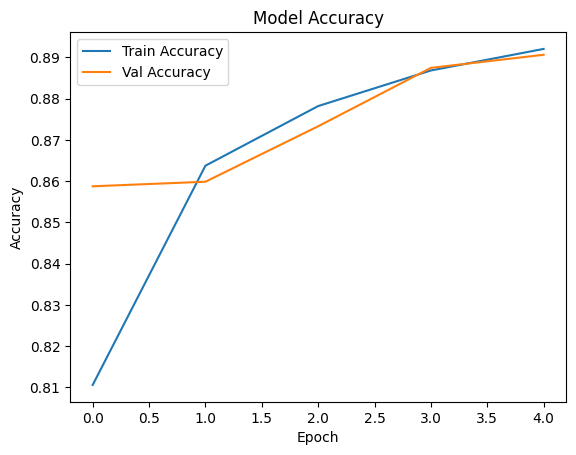

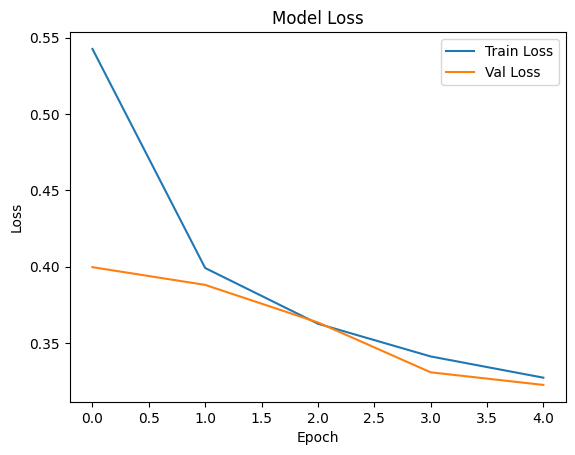

In [ ]:
import matplotlib.pyplot as plt

# Plot accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


2315/2315 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step
              precision    recall  f1-score   support

           0     0.8067    0.8674    0.8360     13862
           1     0.8244    0.6242    0.7104     11580
           2     0.9270    0.9608    0.9436     48610

    accuracy                         0.8907     74052
   macro avg     0.8527    0.8175    0.8300     74052
weighted avg     0.8885    0.8907    0.8870     74052



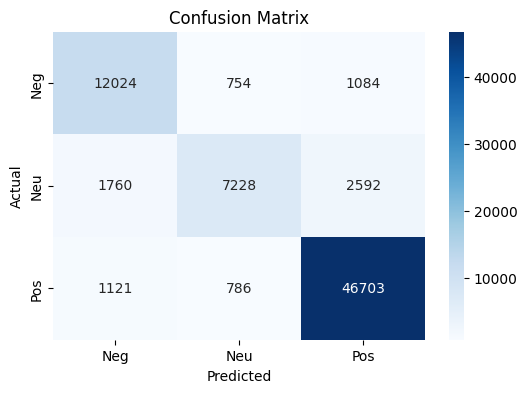

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict class labels
y_pred_probs = model.predict(X_test_pad)
y_pred = np.argmax(y_pred_probs, axis=1)

# Report
print(classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
import seaborn as sns
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Neg', 'Neu', 'Pos'], yticklabels=['Neg', 'Neu', 'Pos'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
model.save("sentiment_bigru_model.h5")


In [ ]:
model.save("sentiment_model.keras")  # Recommended in 2024+


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping

# Parameters
vocab_size = 10000
embedding_dim = 64
max_length = 100

# Define model
model = Sequential([
    Embedding(vocab_size, embedding_dim),
    Bidirectional(GRU(32, return_sequences=False, kernel_regularizer=l2(0.001))),
    Dropout(0.5),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dropout(0.4),
    Dense(3, activation='softmax')  # 3-class classification
])

# Compile
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

# Build model explicitly (optional, for clean summary)
model.build(input_shape=(None, max_length))
model.summary()

# Train
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_test_pad, y_test),
    epochs=10,
    batch_size=128,
    callbacks=[early_stop]
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 64)        │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        18,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 660,995 (2.52 MB)

 Trainable params: 660,995 (2.52 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 371s 158ms/step - accuracy: 0.7489 - loss: 0.7041 - val_accuracy: 0.8554 - val_loss: 0.4091
Epoch 2/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 382s 158ms/step - accuracy: 0.8616 - loss: 0.4067 - val_accuracy: 0.8760 - val_loss: 0.3568
Epoch 3/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 383s 159ms/step - accuracy: 0.8807 - loss: 0.3574 - val_accuracy: 0.8818 - val_loss: 0.3520
Epoch 4/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 377s 157ms/step - accuracy: 0.8888 - loss: 0.3334 - val_accuracy: 0.8831 - val_loss: 0.3333
Epoch 5/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 382s 157ms/step - accuracy: 0.8965 - loss: 0.3192 - val_accuracy: 0.8886 - val_loss: 0.3239
Epoch 6/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 383s 157ms/step - accuracy: 0.9007 - loss: 0.3072 - val_accuracy: 0.8885 - val_loss: 0.3272
Epoch 7/10
2315/2315 ━━━━━━━━━━━━━━━━━━━━ 384s 158ms/step - accuracy: 0.9030 - loss: 0.3001 - val_accuracy: 0.8900 - val_loss: 0.3246


In [ ]:
from tensorflow.keras.layers import BatchNormalization

# Example addition
...
Bidirectional(GRU(32, return_sequences=False, kernel_regularizer=l2(0.001))),
BatchNormalization(),
Dropout(0.5),
...


Ellipsis

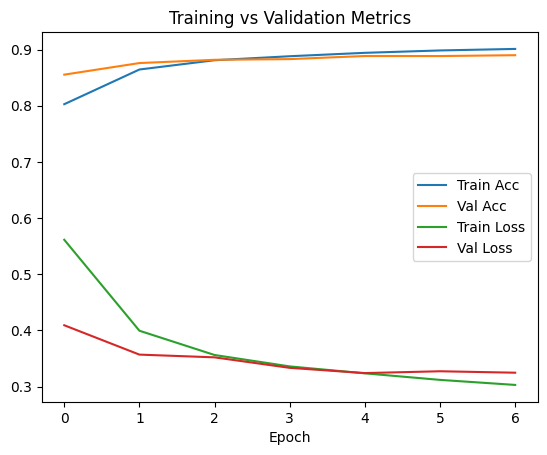

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Training vs Validation Metrics')
plt.xlabel('Epoch')
plt.show()


In [ ]:
from google.colab import files
files.download("text_classifier_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#First Prompt: Explain how  Deep Bidirectional GRU Model with an embedding layer work.
#last prompt: How can I improve my GRU model give me some methods